# Proprioceptive sensing — object stiffness estimation

The hand squeezes a grasped object at two tip-stiffness levels and uses the resulting
position–force finite difference to estimate object compliance without external force sensors.

---

## Why $\Delta x / \Delta F$ recovers $C_O$, not $C_A + C_O$

At first glance it might seem that the measured ratio $\|\Delta x_f\|/\|\Delta F_f\|$ should
reflect the *series* combination of hand compliance $C_A$ and object compliance $C_O$.
It does not — $C_A$ cancels exactly, and the ratio isolates $C_O$ alone.

**Series-spring model (1-D along the contact normal).** Model the fingertip as a VMC spring
$K_A^{(i)} = 1/C_i$ anchored at the fixed reference $d_{\rm ref}$, in series with an object
spring $K_O = 1/C_O$ anchored at the fixed back wall. The total gap
$\delta = d_{\rm ref} - x_{\rm back}$ is the same for both stiffness levels. At equilibrium:

$$F_i = \frac{\delta}{C_i + C_O}, \qquad x_{f,i} = d_{\rm ref} - C_i\,F_i = d_{\rm ref} - \frac{C_i\,\delta}{C_i + C_O}$$

Taking the finite difference between the gentle level ($i=1$, compliance $C_1$) and any probe
level ($i=2$, compliance $C_2 < C_1$):

$$\Delta x = x_{f,2} - x_{f,1} = -\delta\,\frac{C_O\,(C_2 - C_1)}{(C_1+C_O)(C_2+C_O)}$$

$$\Delta F = F_2 - F_1 = \delta\,\frac{C_1 - C_2}{(C_1+C_O)(C_2+C_O)}$$

$$\boxed{\frac{\Delta x}{\Delta F} = \frac{-C_O(C_2-C_1)}{C_1-C_2} = C_O}$$

The hand compliances $C_1$, $C_2$ and the gap $\delta$ all cancel. The formula gives the
**exact** object compliance regardless of the stiffness levels chosen, provided the two
equilibria are distinct and the contact geometry is consistent.

**Intuition.** An absolute deformation measurement (single stiffness level) would give
$\delta_{\rm hand} + \delta_{\rm obj} \propto C_A + C_O$. The two-point finite difference
subtracts two such measurements; because the object deformation changes by $C_O\,\Delta F$
and the hand deformation changes by $C_A\,\Delta F$, the $C_A\,\Delta F$ terms cancel in
$\Delta x$, leaving only the object's contribution.

---

## Quantities

**Active compliance** (VMC model):
$$C_A^f = \frac{1}{\lambda_{\max}(K_x^{(1)})}, \qquad
K_x^{(1)} = (P_f J_{x,f})^{+\top} K_{\rm motor}\,(P_f J_{x,f})^+$$

**Analytic tip force** (VMC prediction):
$$F_f = (P_f J_{x,f})^{+\top} \eta\,\tau_{\rm VMC}, \qquad
\tau_{\rm VMC} = \sum_g J_{\theta,g}^\top K_{\theta,g}\,\Delta\theta_g
              + \sum_p J_{x,p}^\top K_{x,p}\,\Delta x_p$$

**Object compliance** (finite-difference across the $k_{tip}$ sweep):
$$C_O^f(k) = \frac{\|\Delta x_f\|}{\|\Delta F_f\|}, \qquad
\Delta x_f = \bar{x}_f(k) - \bar{x}_f(k_{\rm gentle}),\quad
\Delta F_f = \bar{F}_f(k) - \bar{F}_f(k_{\rm gentle})$$

**Classification metric**:
$$\langle C_O \rangle = \mathrm{mean}_f\, C_O^f(k_{\rm top})$$

Lower $\langle C_O \rangle$ $\Rightarrow$ stiffer object.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys

sys.path.insert(0, os.path.join('../..'))
sys.path.insert(0, '.')
from plot_config import draw_radar
from hand_config import K_TIP_GENTLE, K_TIP_SWEEP, OBJECTS, FINGERTIPS

OUTPUT_DIR = os.path.join('outputs', 'object_stiffness_hand')

K_TIP_GENTLE = float(K_TIP_GENTLE)
K_TIP_SWEEP  = [float(k) for k in K_TIP_SWEEP]
FINGERS = list(FINGERTIPS)

OBJECT_LABELS = ['Sphere', 'Sponge', 'Yarn']

def latest_run(object_name):
    path = os.path.join(OUTPUT_DIR, f'object_stiffness_hand_{object_name}.csv')
    return path if os.path.exists(path) else None

In [2]:
def steady_state(df):
    out = {}
    for k_tip, sub in df.groupby('k_tip_Npm'):
        per_finger = {}
        for f in FINGERS:
            pos  = sub[[f'tip_{f}_x_m', f'tip_{f}_y_m', f'tip_{f}_z_m']].median().to_numpy()
            ref  = sub[[f'ref_{f}_x_m', f'ref_{f}_y_m', f'ref_{f}_z_m']].median().to_numpy()
            F1   = sub[[f'force_1st_{f}_x_N', f'force_1st_{f}_y_N', f'force_1st_{f}_z_N']].median().to_numpy()
            F2   = sub[[f'force_2nd_{f}_x_N', f'force_2nd_{f}_y_N', f'force_2nd_{f}_z_N']].median().to_numpy()
            eig1 = sub[[f'stiff_1st_{f}_eig_0_Npm', f'stiff_1st_{f}_eig_1_Npm', f'stiff_1st_{f}_eig_2_Npm']].median().to_numpy()
            eig2 = sub[[f'stiff_2nd_{f}_eig_0_Npm', f'stiff_2nd_{f}_eig_1_Npm', f'stiff_2nd_{f}_eig_2_Npm']].median().to_numpy()
            per_finger[f] = dict(pos=pos, ref=ref, F1=F1, F2=F2, eig1=eig1, eig2=eig2)
        out[float(k_tip)] = per_finger
    return out


def object_compliance(ss, finger):
    """C_O = ||Delta_pos|| / ||Delta_F|| per sweep level; nan when Delta_F ~ 0."""
    k_levels = sorted(k for k in ss.keys() if abs(k - K_TIP_GENTLE) > 1e-6)
    if K_TIP_GENTLE not in ss:
        return np.array(k_levels), np.full(len(k_levels), np.nan)
    pos_b = ss[K_TIP_GENTLE][finger]['pos']
    F_b   = ss[K_TIP_GENTLE][finger]['F1']
    C = []
    for k in k_levels:
        d_pos = ss[k][finger]['pos'] - pos_b
        d_F   = ss[k][finger]['F1']  - F_b
        nF    = np.linalg.norm(d_F)
        C.append(np.linalg.norm(d_pos) / nF if nF > 1e-12 else np.nan)
    return np.array(k_levels), np.array(C)


# Load latest run per object
data = {}
print('Loading data:')
for obj in OBJECTS:
    f = latest_run(obj)
    if f is None:
        print(f'  {obj:<10s}: no data')
        continue
    df = pd.read_csv(f)
    ss = steady_state(df)
    data[obj] = dict(df=df, ss=ss, file=f)
    print(f'  {obj:<10s}: {os.path.basename(f)} --- k_tip levels {sorted(ss.keys())}')

Loading data:
  hard      : object_stiffness_hand_hard.csv --- k_tip levels [10.0, 50.0, 100.0, 150.0]
  medium    : object_stiffness_hand_medium.csv --- k_tip levels [10.0, 50.0, 100.0, 150.0]
  soft      : object_stiffness_hand_soft.csv --- k_tip levels [10.0, 50.0, 100.0, 150.0]


## Radar helper

`draw_radar_fig` wraps `draw_radar` from `plot_config.py`.
All spokes share the **same radial scale** (global maximum across all fingers, objects,
and $k_{tip}$ levels — no per-spoke normalization).
Nan values (numerically undefined ratio) appear as zero on the radar and as absent
bars in the bar charts.
Grouped bar charts show **raw** per-finger values for each $k_{tip}$ level.

In [3]:
def draw_radar_fig(
    raw,
    k_levels_to_plot,
    save_path,
    ylabel='',
    cmap_name='Blues',
    cmap_lo=0.40,
    cmap_hi=0.90,
    fig_w_per_obj=11,
    fig_h=10,
    r_lim=1.25,
    r_label=1.30,
    fs_fingers=25,
    fs_obj=40,
    fs_legend=30,
    lw_last=3.5,
    lw_other=2.2,
    alpha_last=0.22,
    alpha_other=0.10,
    markersize=7,
):
    objects_with_data = [obj for obj in OBJECTS if obj in data]
    if not objects_with_data:
        print(f'No data available -- skipping {os.path.basename(save_path)}')
        return

    # Single global max: all spokes on the same physical scale.
    all_vals = [
        raw[(obj, f, k)]
        for obj in OBJECTS for f in FINGERS for k in k_levels_to_plot
        if (obj, f, k) in raw and np.isfinite(raw[(obj, f, k)])
    ]
    global_max = max(all_vals) if all_vals else 1.0
    vmax_arr   = np.full(len(FINGERS), global_max)

    N     = len(FINGERS)
    n_lev = len(k_levels_to_plot)

    cmap = mpl.colormaps[cmap_name]
    level_colors = [cmap(cmap_lo + (cmap_hi - cmap_lo) * i / max(n_lev - 1, 1))
                    for i in range(n_lev)]

    # -- Radar ------------------------------------------------------------
    fig_radar = plt.figure(figsize=(fig_w_per_obj * len(objects_with_data), fig_h))

    for oi, obj in enumerate(objects_with_data):
        ax_radar = fig_radar.add_subplot(1, len(objects_with_data), oi + 1,
                                         projection='polar')

        traces = []
        for li, k in enumerate(k_levels_to_plot):
            vals = []
            for f in FINGERS:
                v = raw.get((obj, f, k), np.nan)
                vals.append(v if np.isfinite(v) else 0.0)
            traces.append({
                'label':  k if isinstance(k, str) else rf'$k_{{tip}}={k:.0f}$ N/m',
                'values': vals,
                'color':  level_colors[li],
                'lw':     lw_last  if li == n_lev - 1 else lw_other,
                'alpha':  alpha_last if li == n_lev - 1 else alpha_other,
            })

        draw_radar(FINGERS, traces, ax=ax_radar, vmax=vmax_arr,
                   r_lim=r_lim, r_label=r_label, fs_spokes=fs_fingers,
                   markersize=markersize)

        lbl_obj = OBJECT_LABELS[OBJECTS.index(obj)] if obj in OBJECTS else obj
        ax_radar.annotate(lbl_obj, xy=(0.5, -0.10), xycoords='axes fraction',
                          ha='center', va='top', fontsize=fs_obj, fontweight='bold')

    legend_handles, legend_labels = fig_radar.axes[0].get_legend_handles_labels()
    fig_radar.legend(legend_handles, legend_labels,
                     loc='upper center', bbox_to_anchor=(0.5, 1.15),
                     ncol=n_lev, fontsize=fs_legend, frameon=False,
                     handlelength=3.0, columnspacing=2.5)
    plt.tight_layout()
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    fig_radar.savefig(save_path, bbox_inches='tight')
    plt.show()

    # -- Per-finger grouped bar chart (raw values) -------------------------
    fig_bar, axes_bar = plt.subplots(
        1, len(objects_with_data),
        figsize=(fig_w_per_obj * len(objects_with_data), fig_h * 0.70),
        sharey=True,
    )
    if len(objects_with_data) == 1:
        axes_bar = [axes_bar]

    x     = np.arange(N)
    width = 0.75 / n_lev

    for ai, obj in enumerate(objects_with_data):
        ax_bar = axes_bar[ai]
        for li, k in enumerate(k_levels_to_plot):
            vals   = [raw.get((obj, f, k), np.nan) for f in FINGERS]
            offset = (li - (n_lev - 1) / 2.0) * width
            label  = k if isinstance(k, str) else rf'$k_{{tip}}={k:.0f}$ N/m'
            ax_bar.bar(x + offset, vals, width,
                       color=level_colors[li], alpha=0.85,
                       edgecolor=level_colors[li],
                       linewidth=lw_last if li == n_lev - 1 else lw_other,
                       label=label)

        ax_bar.set_xticks(x)
        ax_bar.set_xticklabels([f.capitalize() for f in FINGERS],
                               fontsize=fs_fingers * 0.75)
        ax_bar.tick_params(axis='y', labelsize=fs_fingers * 0.75)
        ax_bar.grid(axis='y', linestyle='--', alpha=0.4)
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)
        lbl_obj = OBJECT_LABELS[OBJECTS.index(obj)] if obj in OBJECTS else obj
        ax_bar.set_title(lbl_obj, fontsize=fs_obj, fontweight='bold', pad=20)
        if ai == 0 and ylabel:
            ax_bar.set_ylabel(ylabel, fontsize=fs_fingers * 0.85)

    bar_handles, bar_labels = axes_bar[0].get_legend_handles_labels()
    fig_bar.legend(bar_handles, bar_labels,
                   loc='upper center', bbox_to_anchor=(0.5, 1.15),
                   ncol=n_lev, fontsize=fs_legend, frameon=False,
                   handlelength=3.0, columnspacing=2.5)
    fig_bar.tight_layout()
    base, ext = os.path.splitext(save_path)
    fig_bar.savefig(f'{base}_bars{ext}', bbox_inches='tight')
    plt.show()

## Object compliance $C_O$ per finger

$C_O = \|\Delta x_f\| / \|\Delta F_f\|$ estimated via finite difference between the gentle baseline ($k_{tip}=10$ N/m) and each sweep level. Each layer is one $k_{tip}$ level; black = highest stiffness.

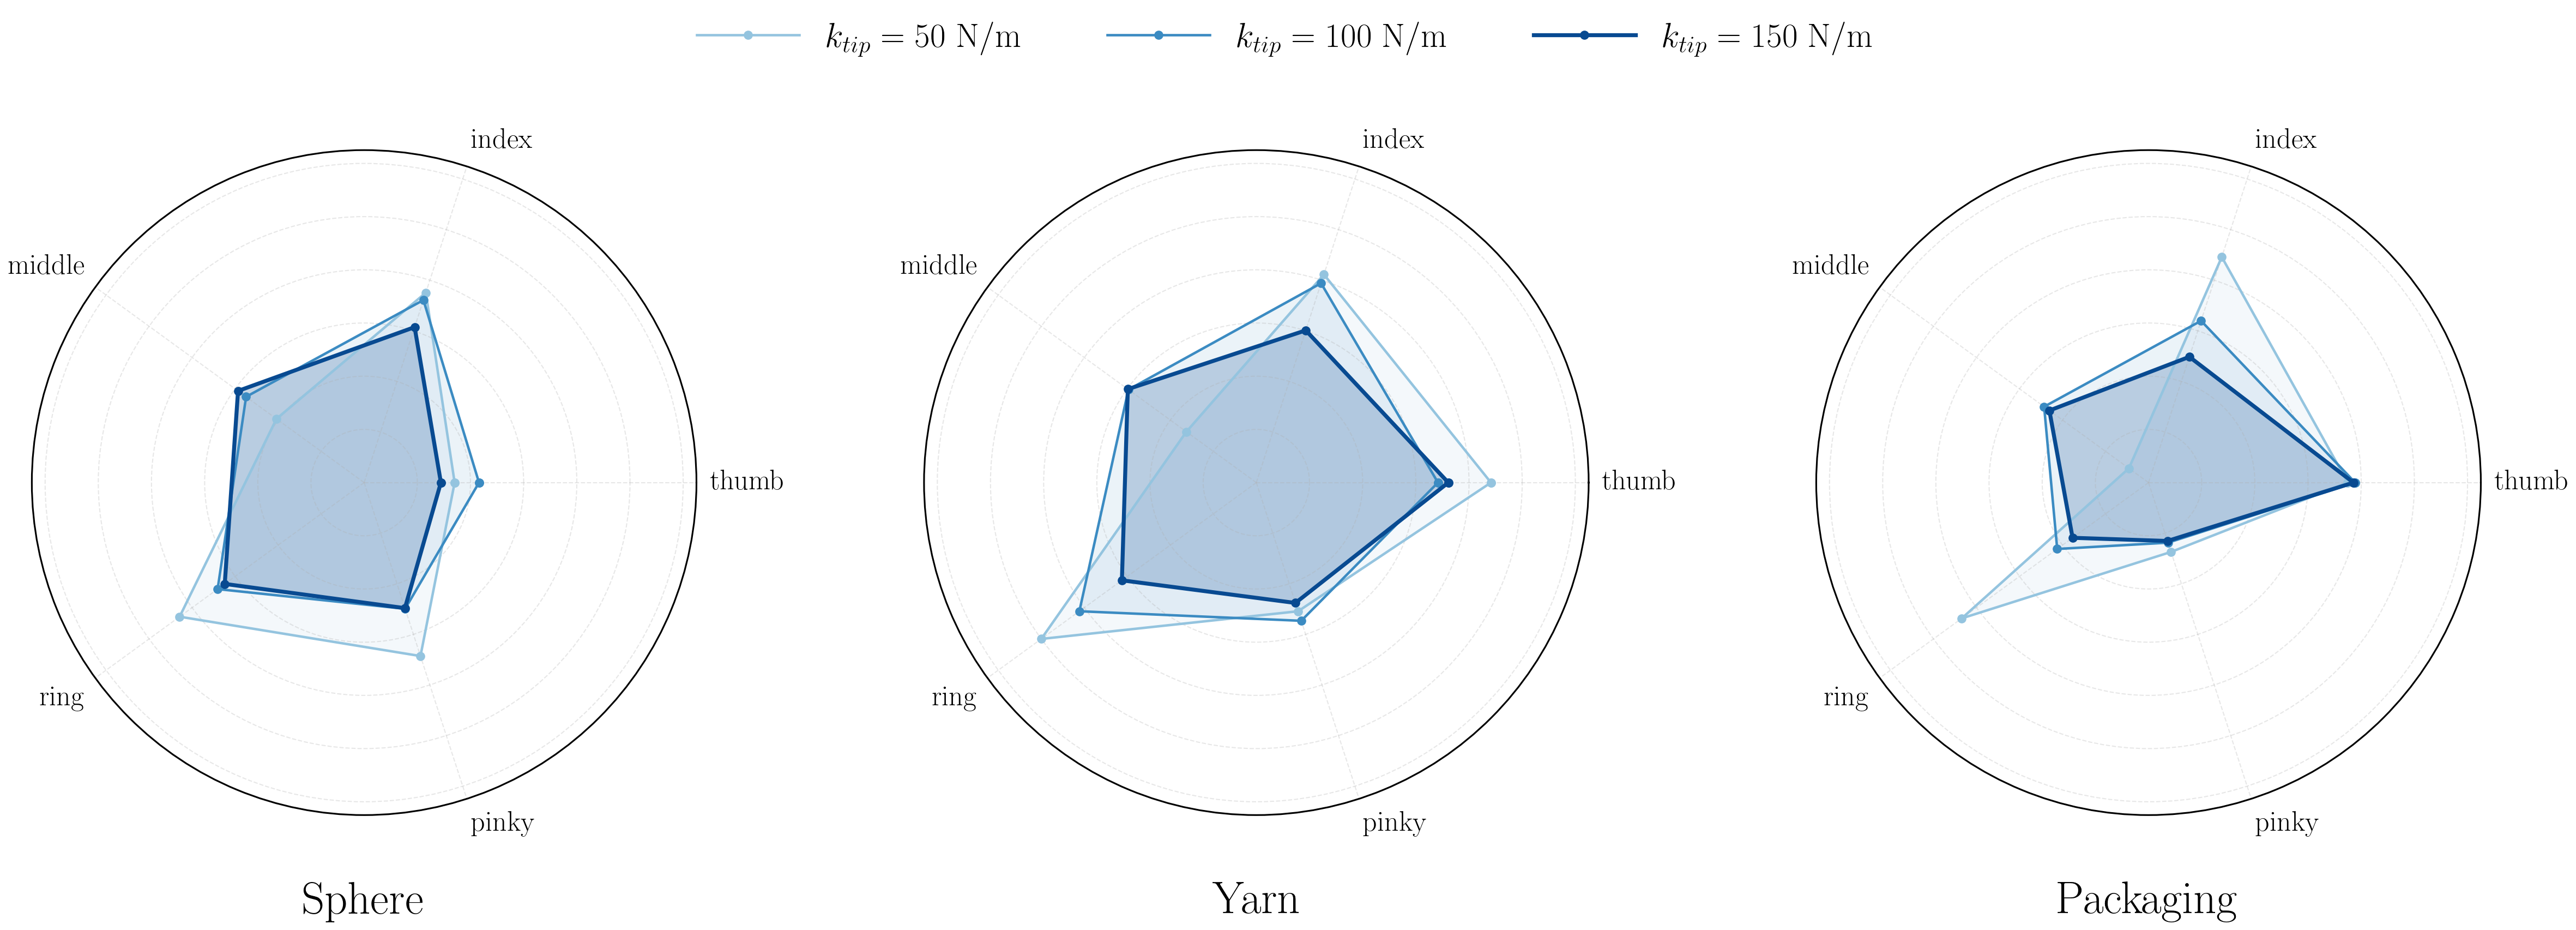

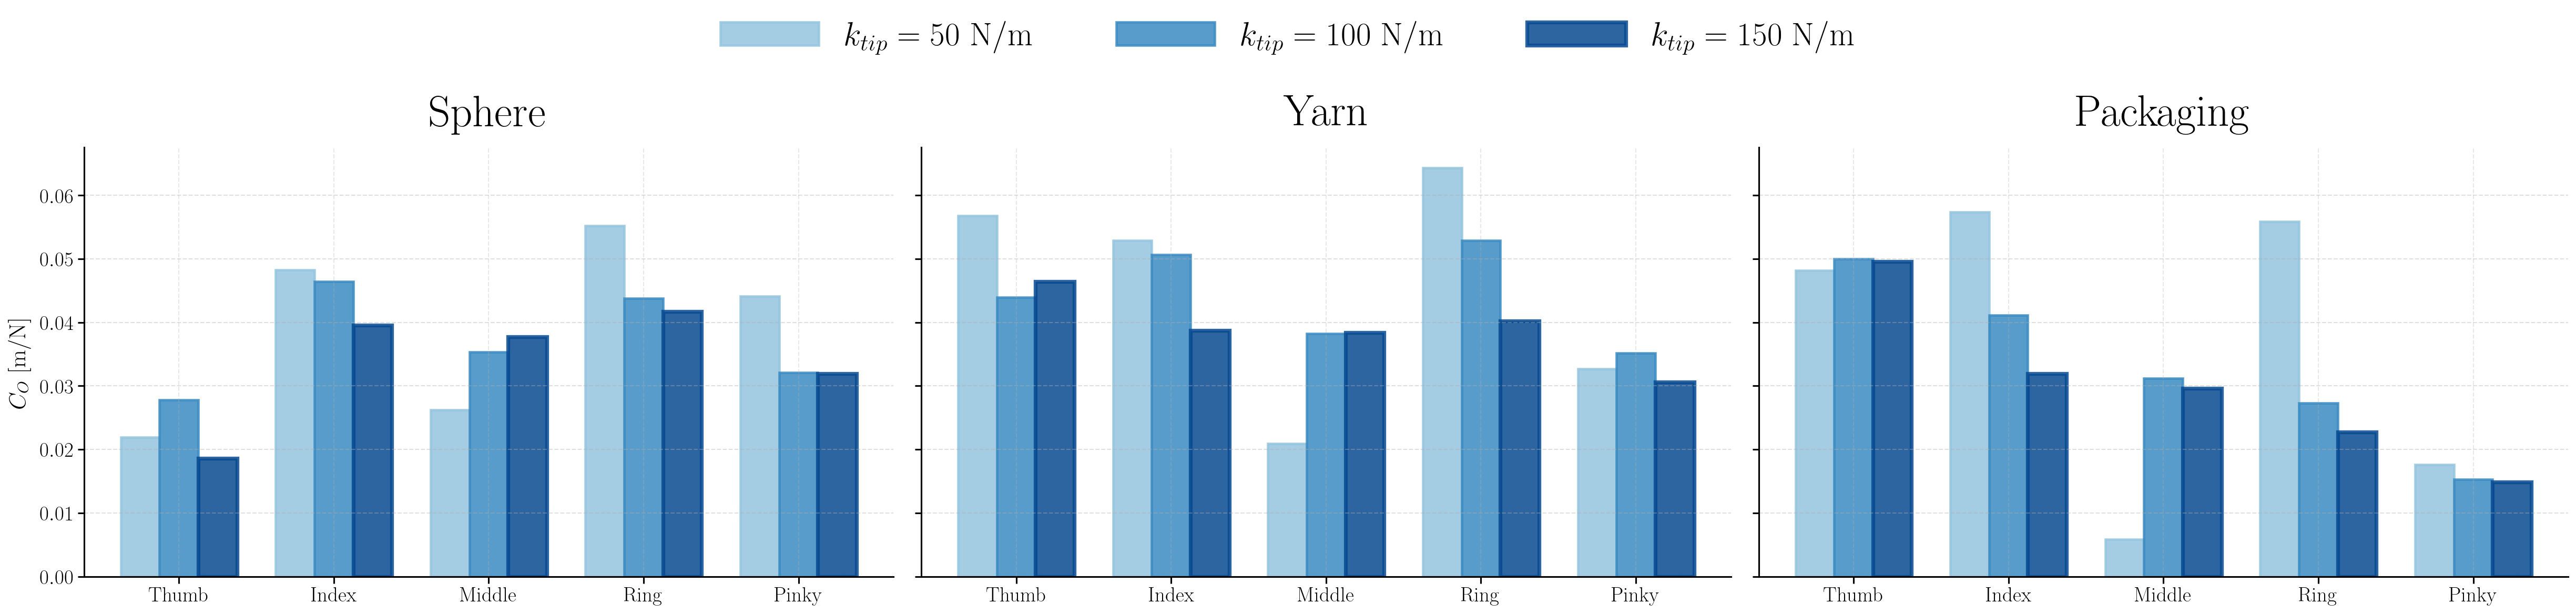

In [4]:
co_raw = {}
for obj in OBJECTS:
    if obj not in data:
        continue
    for f in FINGERS:
        k_arr, C_arr = object_compliance(data[obj]['ss'], f)
        for k, c in zip(k_arr, C_arr):
            co_raw[(obj, f, float(k))] = c

sweep_levels = sorted({k for _, _, k in co_raw})
draw_radar_fig(co_raw, sweep_levels,
               os.path.join(OUTPUT_DIR, 'radar_compliance.pdf'),
               ylabel=r'$C_O$ [m/N]',
               cmap_name='Blues')

## Tip displacement per finger

FK tip displacement $\|\Delta x_f\| = \|p_f(k_{tip}) - p_f(k_{gentle})\|$ for each sweep level. Shows which fingers deflect most as the controller stiffens.

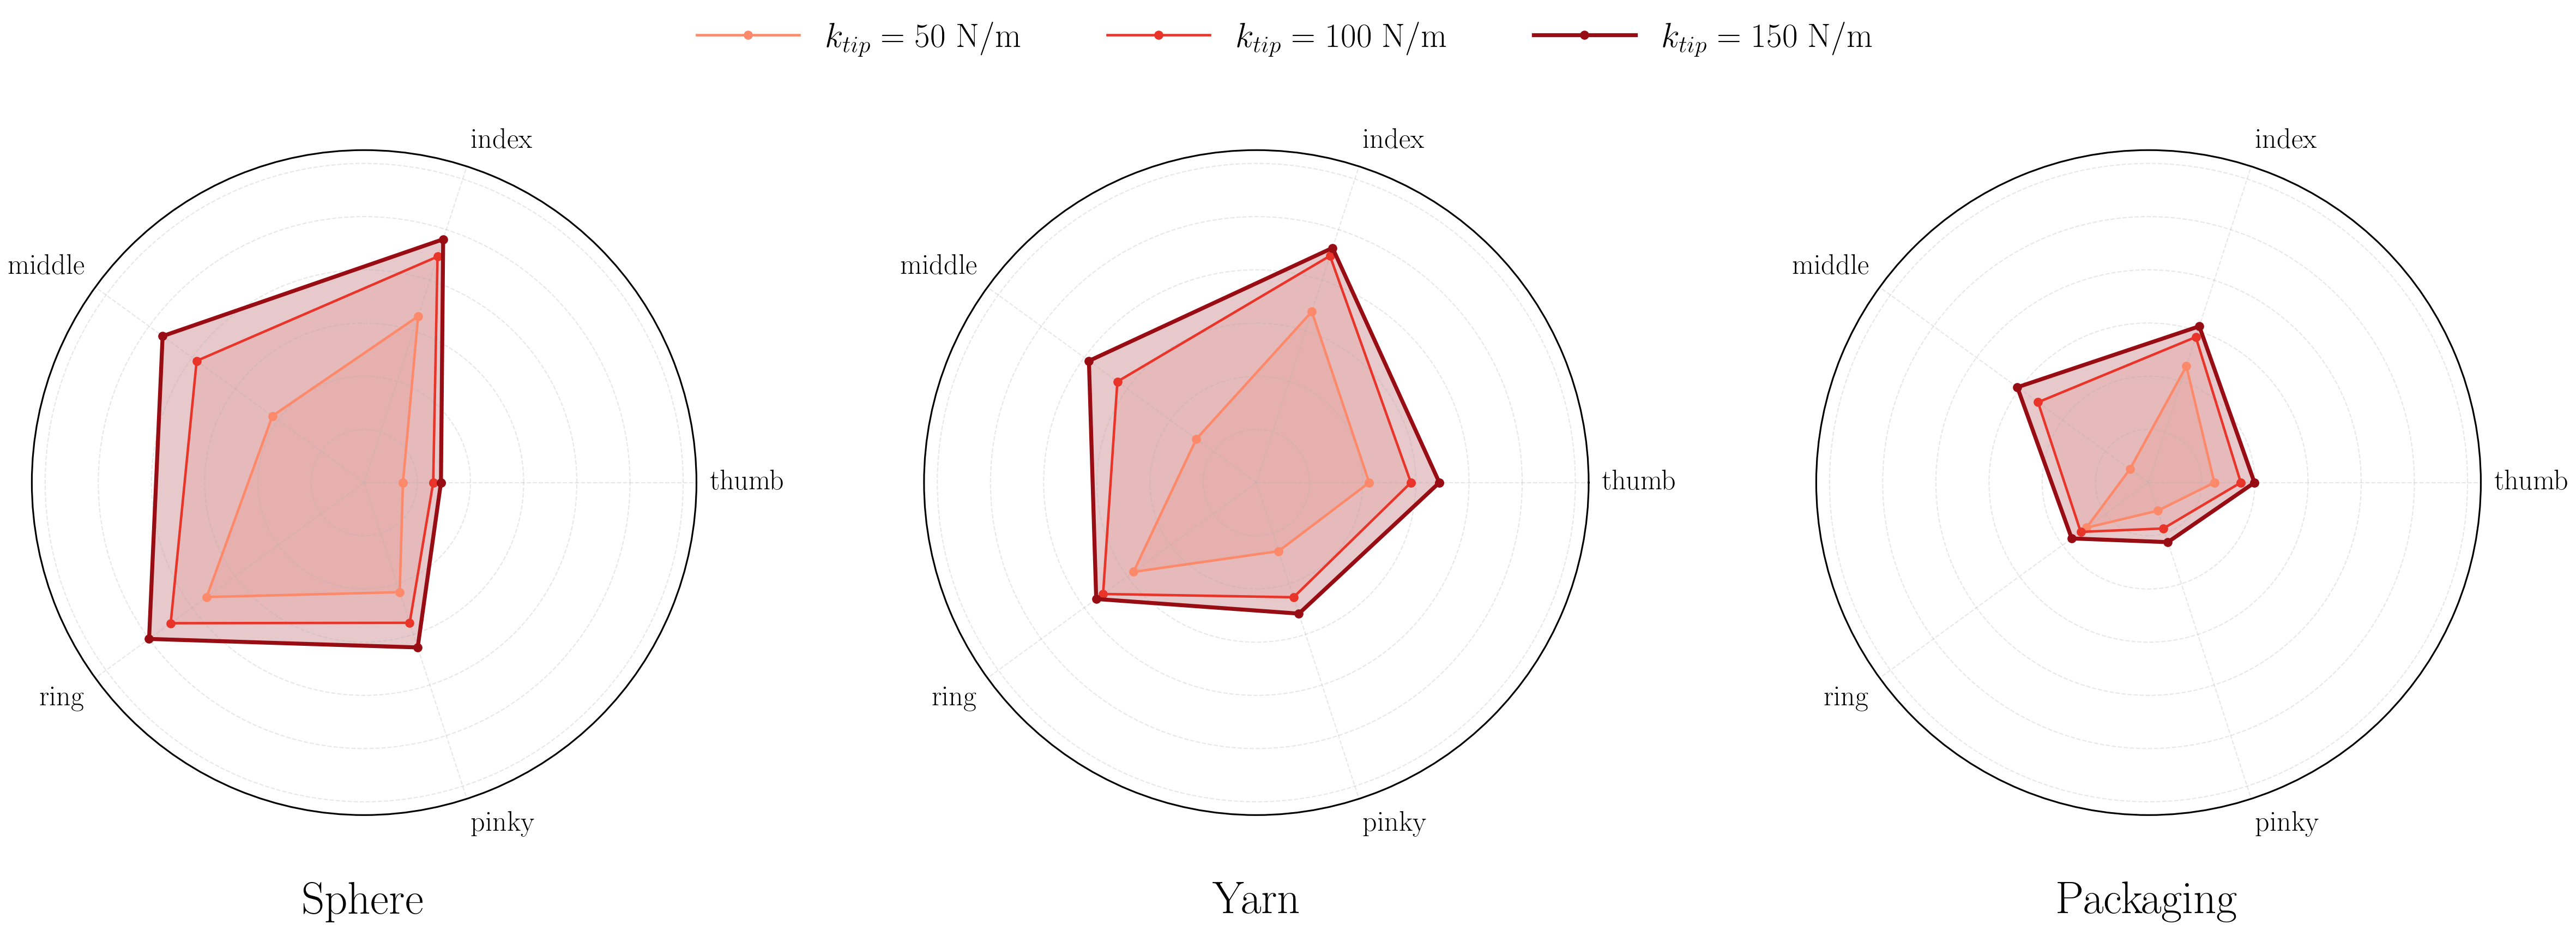

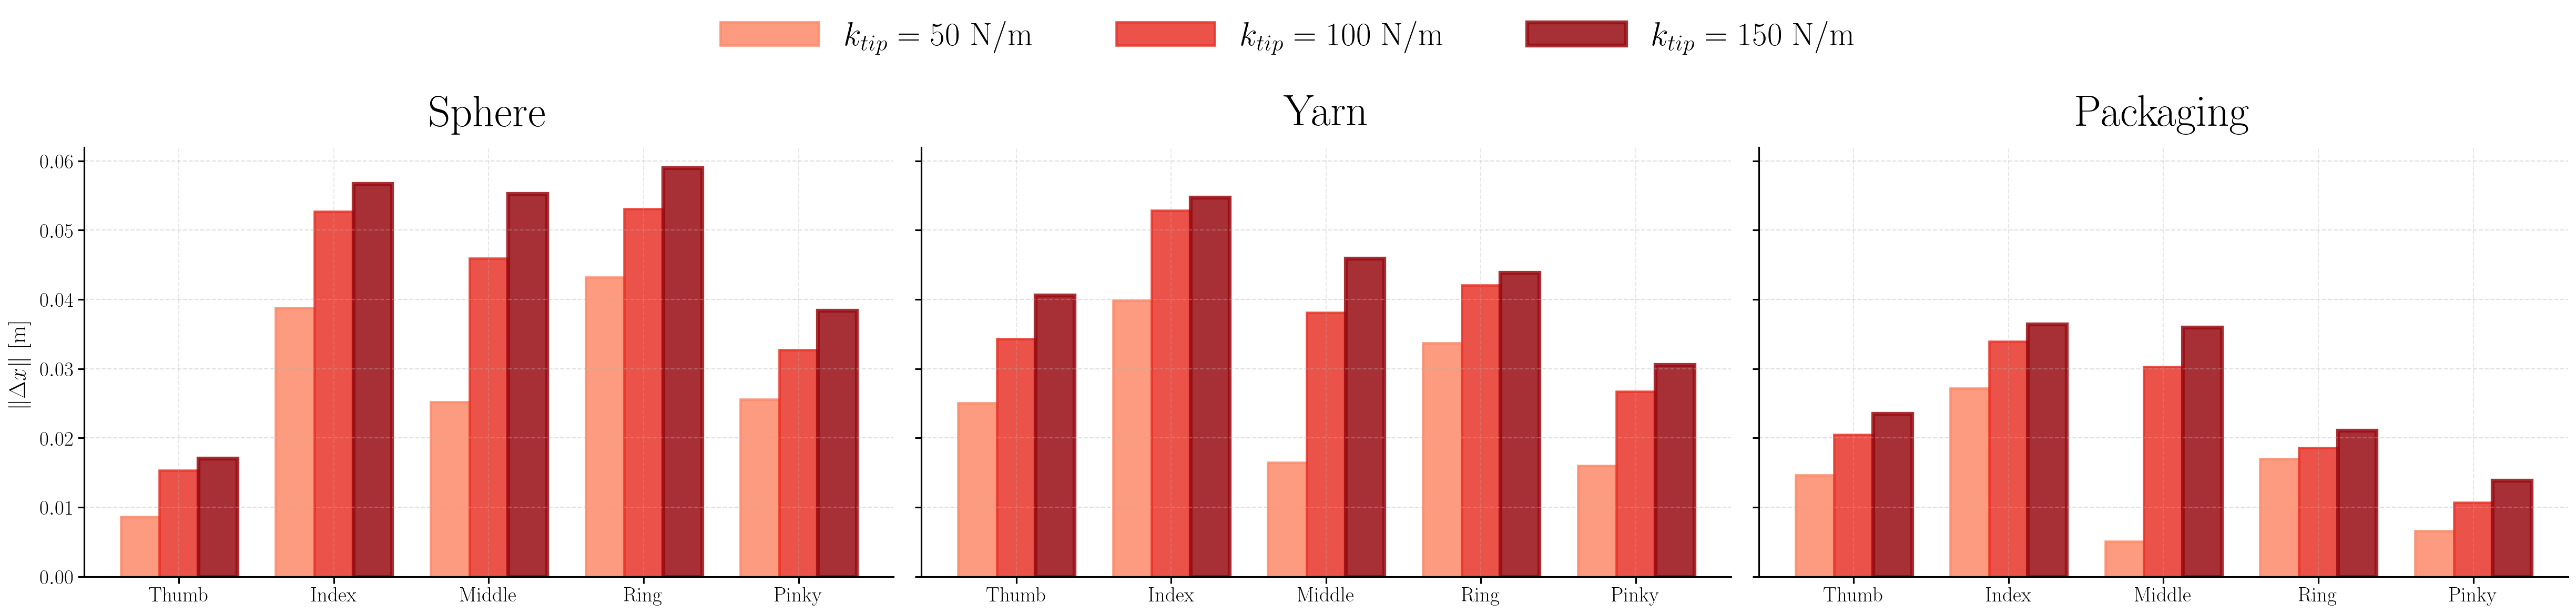

In [5]:
disp_raw = {}
for obj in OBJECTS:
    if obj not in data:
        continue
    ss   = data[obj]['ss']
    base = {f: ss[K_TIP_GENTLE][f]['pos'] for f in FINGERS}
    for k, per_f in ss.items():
        for f in FINGERS:
            disp_raw[(obj, f, float(k))] = np.linalg.norm(per_f[f]['pos'] - base[f])

disp_levels = sorted(k for k in {k for _, _, k in disp_raw} if abs(k - K_TIP_GENTLE) > 1e-6)
draw_radar_fig(disp_raw, disp_levels,
               os.path.join(OUTPUT_DIR, 'radar_displacement.pdf'),
               ylabel=r'$\|\Delta x\|$ [m]',
               cmap_name='Reds')

## Contact force per finger

1st-order VMC force magnitude $\|F_f\|$ at each $k_{tip}$ level. Reveals the load distribution across fingers and how it evolves with controller stiffness.

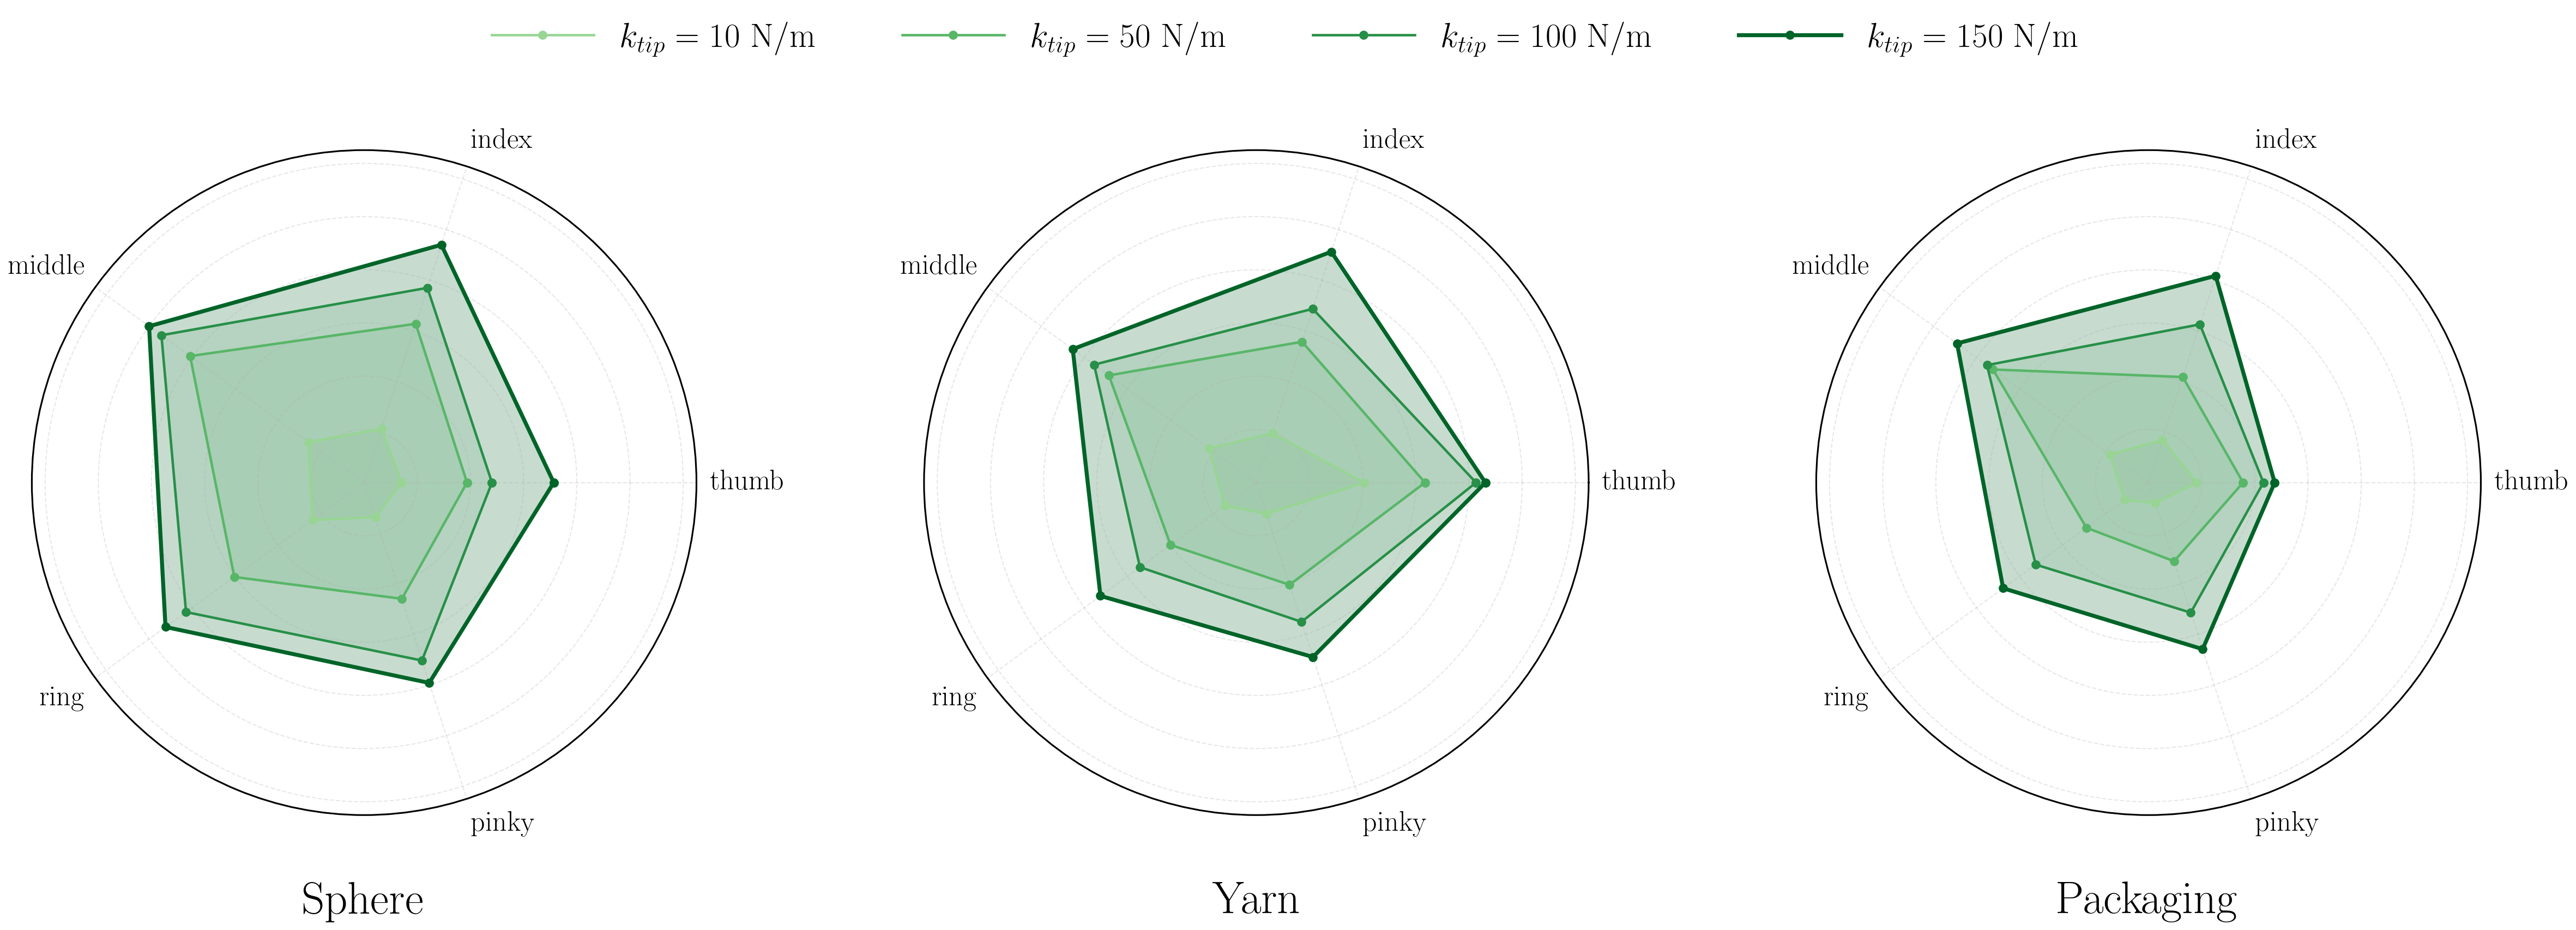

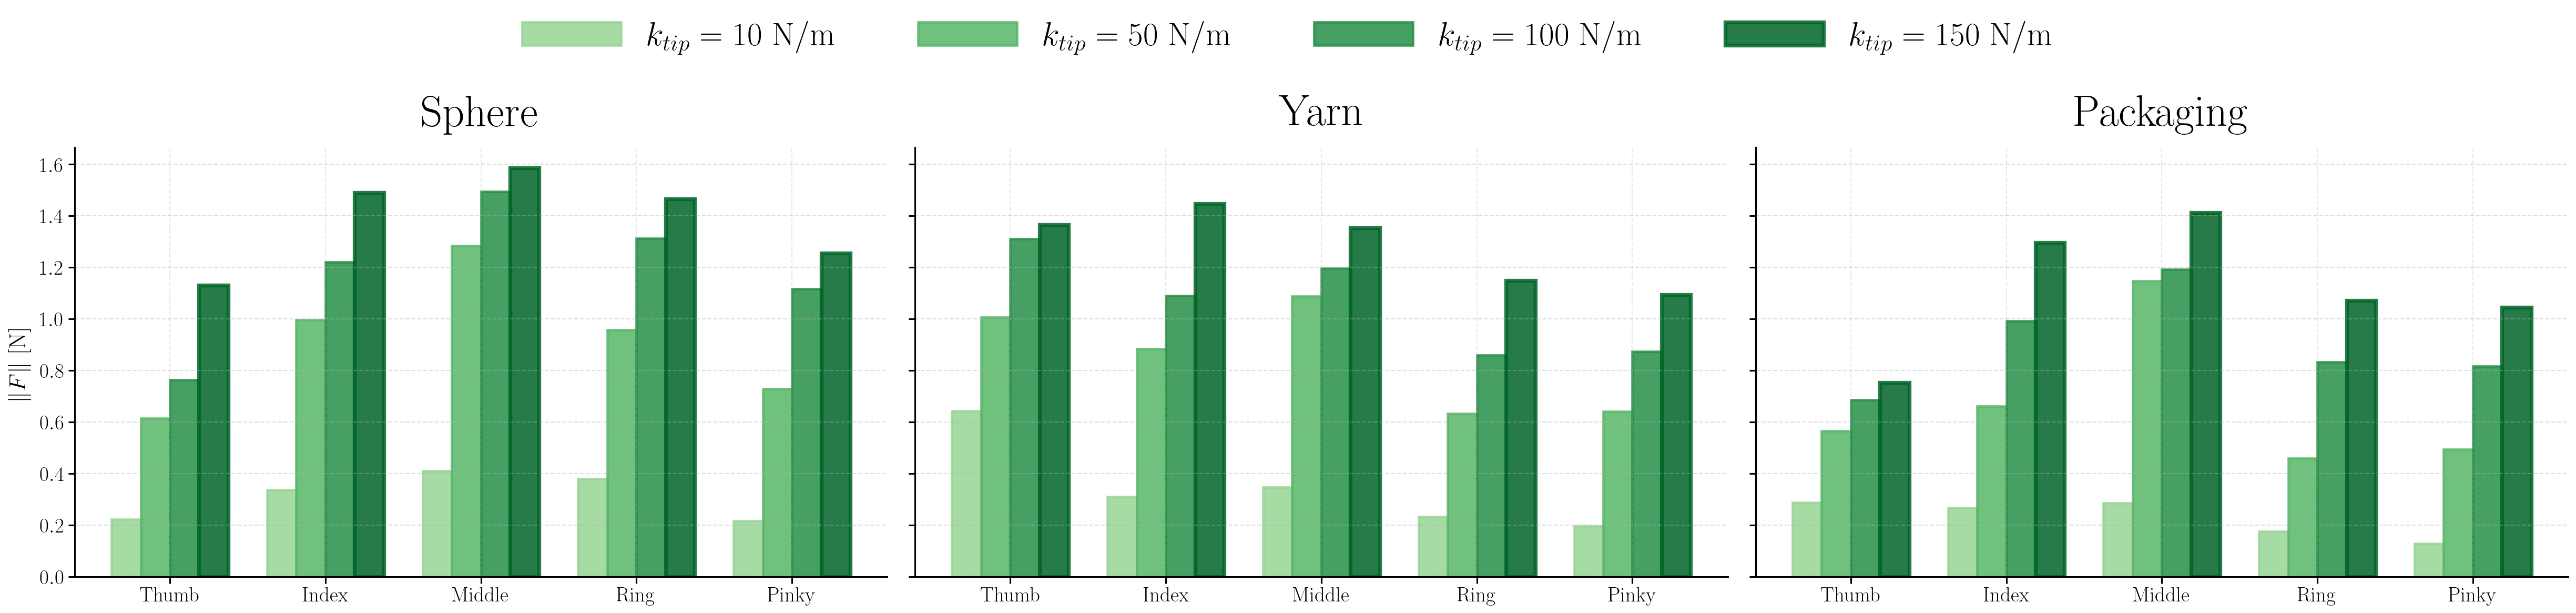

In [6]:
force_raw = {}
for obj in OBJECTS:
    if obj not in data:
        continue
    for k, per_f in data[obj]['ss'].items():
        for f in FINGERS:
            force_raw[(obj, f, float(k))] = np.linalg.norm(per_f[f]['F1'])

force_levels = sorted({k for _, _, k in force_raw})
draw_radar_fig(force_raw, force_levels,
               os.path.join(OUTPUT_DIR, 'radar_force.pdf'),
               ylabel=r'$\|F\|$ [N]',
               cmap_name='Greens')

## Model compliance $C_A$ per finger

$C_A = 1/\lambda_{max}(K_x)$ at the gentle baseline ($k_{tip}=10$ N/m). Two layers: 1st-order model (blue) and 2nd-order CCT-corrected model (black). Per-finger normalization.

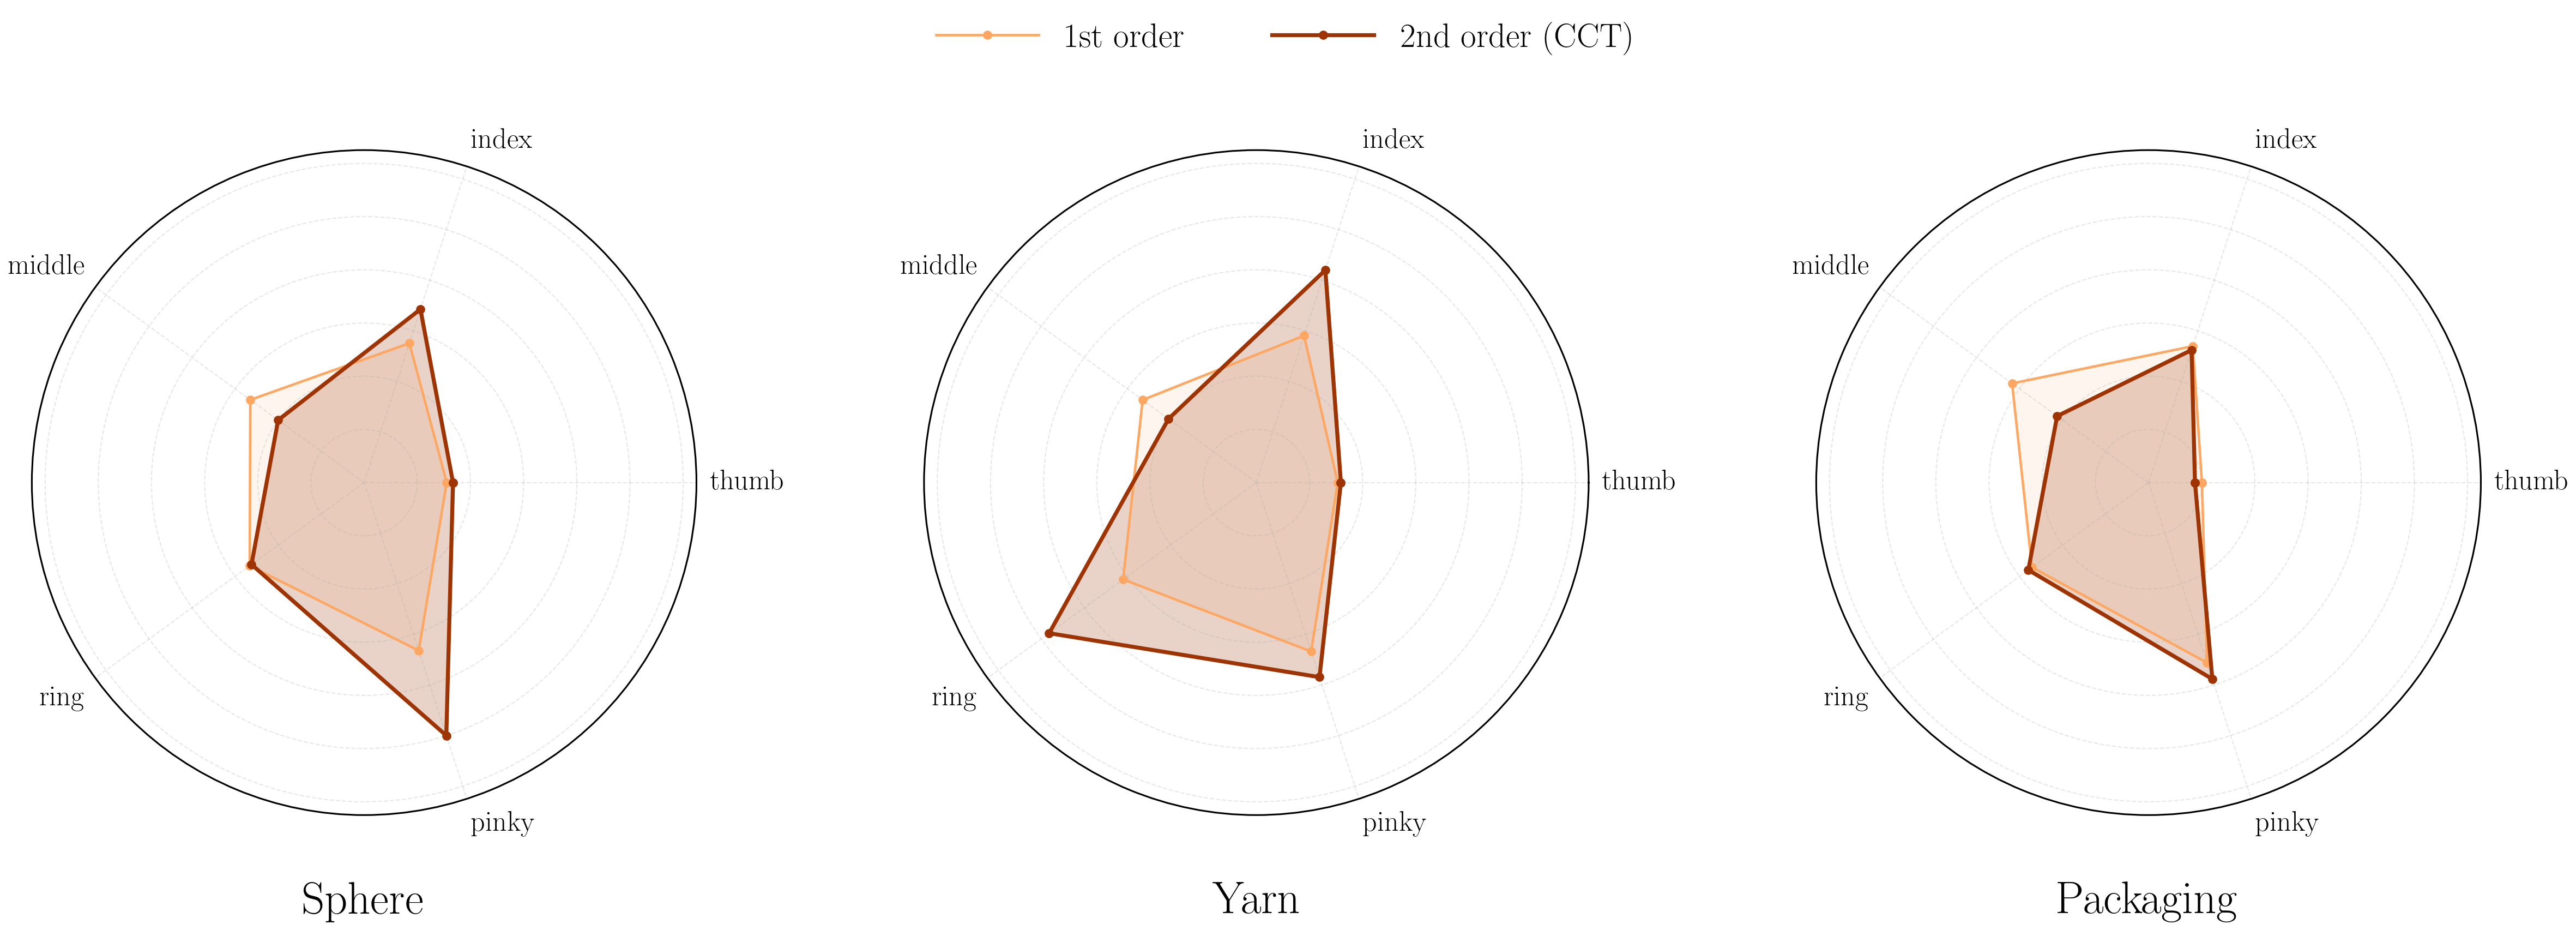

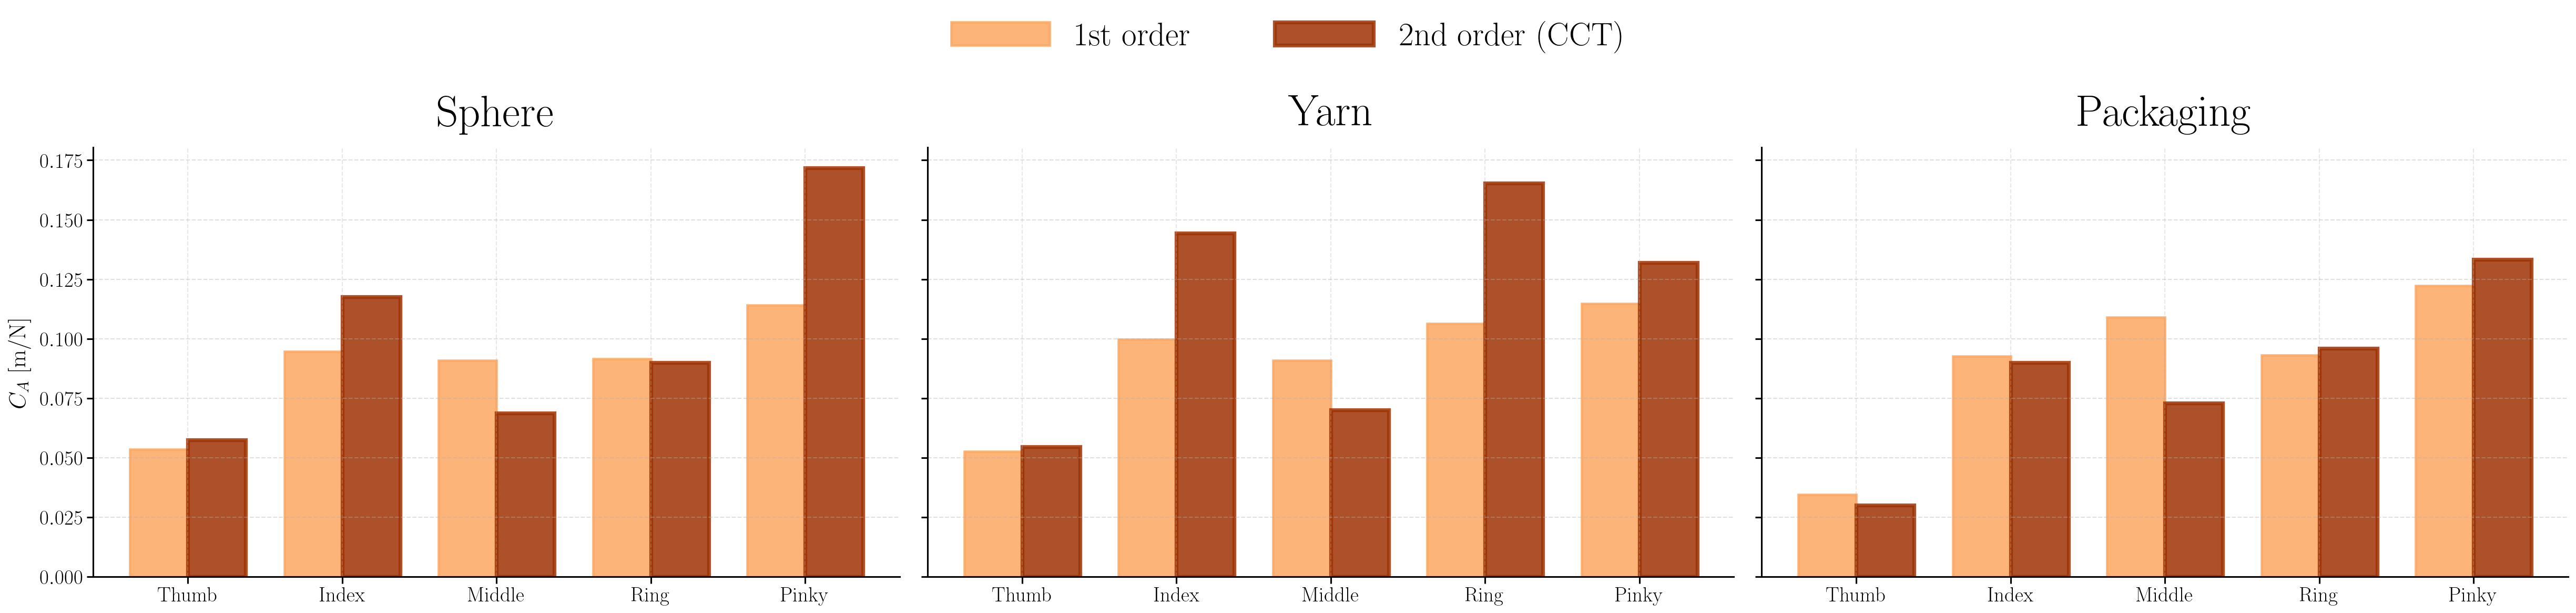

In [7]:
ca_raw = {}

for obj in OBJECTS:
    if obj not in data or K_TIP_GENTLE not in data[obj]['ss']:
        continue
    ss = data[obj]['ss']

    for f in FINGERS:
        e1 = ss[K_TIP_GENTLE][f]['eig1'].max()
        e2 = ss[K_TIP_GENTLE][f]['eig2'].max()

        ca_raw[(obj, f, '1st order')]       = 1.0 / e1 if e1 > 1e-12 else np.nan
        ca_raw[(obj, f, '2nd order (CCT)')] = 1.0 / e2 if e2 > 1e-12 else np.nan

model_levels = ['1st order', '2nd order (CCT)']

draw_radar_fig(
    ca_raw,
    model_levels,
    os.path.join(OUTPUT_DIR, 'radar_compliance_model.pdf'),
    ylabel=r'$C_A$ [m/N]',
    cmap_name='Oranges',
)

## Object classification by compliance

Objects sorted by mean object compliance $\langle C_O \rangle_f$ at the highest
$k_{tip}$ level. The mean is taken over fingers that have a finite $C_O$ value.
Threshold midpoints between consecutive $C_O$ values separate stiff / medium / soft.

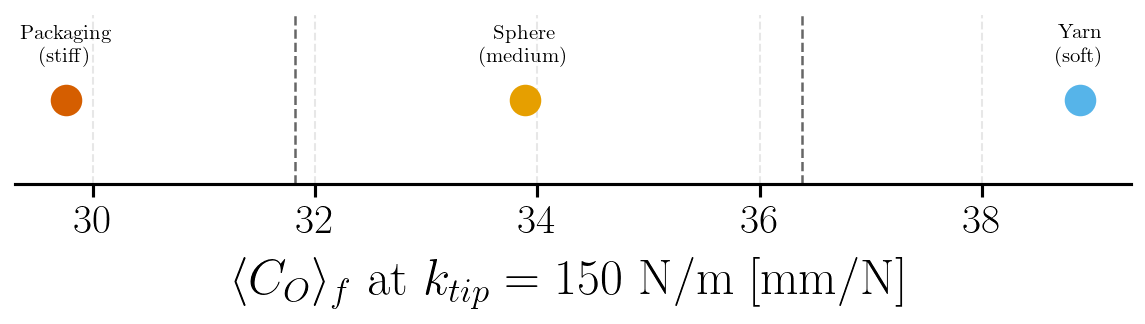

Object classification (by compliance C_O):
  Packaging   C_O = 29.76 mm/N  -->  stiff
  Sphere      C_O = 33.89 mm/N  -->  medium
  Yarn        C_O = 38.88 mm/N  -->  soft


In [8]:
K_TOP = max(K_TIP_SWEEP)

C_O_mean = {}

for obj in OBJECTS:
    if obj not in data:
        continue
    ss = data[obj]['ss']
    if K_TOP not in ss or K_TIP_GENTLE not in ss:
        continue
    C_vals = []
    for f in FINGERS:
        d_pos = ss[K_TOP][f]['pos'] - ss[K_TIP_GENTLE][f]['pos']
        d_F   = ss[K_TOP][f]['F1']  - ss[K_TIP_GENTLE][f]['F1']
        nF    = np.linalg.norm(d_F)
        if nF > 1e-12:
            C_vals.append(float(np.linalg.norm(d_pos) / nF))
    if C_vals:
        C_O_mean[obj] = float(np.nanmean(C_vals))

if not C_O_mean:
    print('No data available -- skipping object classification.')
else:
    sorted_objs    = sorted(C_O_mean, key=C_O_mean.get)
    cluster_labels = {sorted_objs[i]: lbl
                      for i, lbl in enumerate(['stiff', 'medium', 'soft'][:len(sorted_objs)])}
    cluster_colors = {'stiff': '#D55E00', 'medium': '#E69F00', 'soft': '#56B4E9'}

    vals       = [C_O_mean[o] for o in sorted_objs]
    thresholds = [(vals[i] + vals[i+1]) / 2 for i in range(len(vals) - 1)]

    fig, ax = plt.subplots(figsize=(8, 2.5))

    for obj in sorted_objs:
        lbl   = cluster_labels[obj]
        color = cluster_colors.get(lbl, 'gray')
        oi    = OBJECTS.index(obj)
        name  = OBJECT_LABELS[oi] if oi < len(OBJECT_LABELS) else obj
        ax.scatter([C_O_mean[obj] * 1e3], [0], color=color, s=200, zorder=5)
        ax.annotate(
            f'{name}\n({lbl})',
            (C_O_mean[obj] * 1e3, 0),
            textcoords='offset points', xytext=(0, 18),
            ha='center', fontsize=10,
        )

    for thr in thresholds:
        ax.axvline(thr * 1e3, color='0.4', lw=1.2, linestyle='--')

    ax.set_xlabel(
        r'$\langle C_O \rangle_f$ at $k_{tip}=' + f'{K_TOP:.0f}$' + r' N/m  [mm/N]'
    )
    ax.set_yticks([])
    ax.spines[['left', 'top', 'right']].set_visible(False)
    fig.tight_layout()
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, 'object_classification.pdf'), bbox_inches='tight')
    plt.show()

    print('Object classification (by compliance C_O):')
    for obj in sorted_objs:
        oi   = OBJECTS.index(obj)
        name = OBJECT_LABELS[oi] if oi < len(OBJECT_LABELS) else obj
        print(f'  {name:<10s}  C_O = {C_O_mean[obj]*1e3:.2f} mm/N  -->  {cluster_labels[obj]}')